In [83]:
import geopandas as gpd
from simpledbf import Dbf5
from osgeo import gdal

import pandas as pd

from PIL import Image
import tifffile

import matplotlib.pyplot as plt

from shapely.geometry import Polygon

import folium

In [84]:
# SHP file
shapefile = gpd.read_file("izium_building_damage_data_sample.shp")

# DBF file. Contains all columns of .shp file except geometry
dbf = Dbf5('izium_building_damage_data_sample.dbf')
polygons_without_geometry = dbf.to_dataframe()

# .fix file is not relevant

# TIF file
tif = gdal.Open("izium_timestamped_damage_data_sample.tif")

def damage_area_to_broken_windows(damage_area):
    """ 
    TODO: map damage area to broken windows using
     reasonable assumptions.
    """
    return damage_area

In [85]:
# rename damgeArea to damageArea (correct typo)
shapefile.rename(columns={'damgeArea': 'damageArea'}, inplace=True)
shapefile

,FID,area,damage,geoType,damageArea,geometry
0,787200,17.037412,0,Polygon,0.000000,"POLYGON ((37.29570 49.15628, 37.29576 49.15629..."
1,394240,85.386360,0,Polygon,0.000000,"POLYGON ((37.29564 49.15637, 37.29577 49.15638..."
2,526848,174.095649,0,Polygon,137.506196,"POLYGON ((37.29471 49.12208, 37.29478 49.12216..."
3,396288,30.788053,0,Polygon,0.000000,"POLYGON ((37.23952 49.12633, 37.23956 49.12636..."
4,462592,99.494457,0,Polygon,0.000000,"POLYGON ((37.29381 49.16493, 37.29399 49.16496..."
...,...,...,...,...,...,...
45387,784127,96.088002,0,Polygon,0.000000,"POLYGON ((37.23768 49.21449, 37.23777 49.21451..."
45388,587775,36.463203,0,Polygon,0.000000,"POLYGON ((37.32442 49.20085, 37.32449 49.20086..."
45389,784639,100.884365,0,Polygon,0.000000,"POLYGON ((37.26605 49.21049, 37.26607 49.21058..."
45390,916479,363.195655,0,Polygon,0.000000,"POLYGON ((37.27074 49.22442, 37.27079 49.22445..."


In [86]:
# there are ~2000 damaged buildings in Izium, according to the model
shapefile.damage.value_counts()

0    43381
1     2011
Name: damage, dtype: int64

In [87]:
# take only buildings with damage
shapefile_subset = shapefile[shapefile.damage == 1]
shapefile_subset

,FID,area,damage,geoType,damageArea,geometry
11,487168,54.240521,1,Polygon,54.382052,"POLYGON ((37.29680 49.12380, 37.29685 49.12383..."
37,834305,122.058642,1,Polygon,122.405271,"POLYGON ((37.29403 49.15925, 37.29408 49.15925..."
40,315137,89.367466,1,Polygon,89.598869,"POLYGON ((37.29934 49.12621, 37.29941 49.12628..."
46,529666,182.161138,1,Polygon,178.896922,"POLYGON ((37.30137 49.12200, 37.30141 49.12203..."
68,147971,129.577698,1,Polygon,122.438750,"POLYGON ((37.30464 49.12766, 37.30477 49.12774..."
...,...,...,...,...,...,...
45325,823807,117.461099,1,Polygon,117.791441,"POLYGON ((37.26056 49.22724, 37.26069 49.22727..."
45338,108031,178.470580,1,Polygon,178.995127,"POLYGON ((37.25308 49.20090, 37.25322 49.20092..."
45359,116991,94.537726,1,Polygon,94.801216,"POLYGON ((37.26875 49.19230, 37.26881 49.19237..."
45371,57343,170.899511,1,Polygon,171.404518,"POLYGON ((37.25854 49.22961, 37.25882 49.22966..."


In [88]:
# coordinates of the first building
coords = shapefile_subset.geometry.iloc[0].exterior.coords.xy 

In [89]:
# Create a folium map centered around the first point of the polygon
m = folium.Map(location=[coords[0][1], coords[0][0]], zoom_start=15)

# get coordinates of all buildings
all_coords = []
for row in shapefile_subset.iterrows():
    coords = row[1]['geometry'].exterior.coords[:]
    all_coords.append(coords)

# get polygons from coordinates
all_polygons = [Polygon(coords) for coords in all_coords]

# get map objects from polygons to draw them on the map
all_gdfs = [gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[polygon]) for polygon in all_polygons]

# add polygons to the map 
# (takes about 20 seconds to do all above instructions
# on M2 MacBook Pro; probably is a more efficient way to do this)
for gdf in all_gdfs:
    folium.GeoJson(gdf).add_to(m)

In [90]:

# Save the map to an HTML file
m.save('polygon_map.html')

# Display the map (optional, depends on the environment)
m

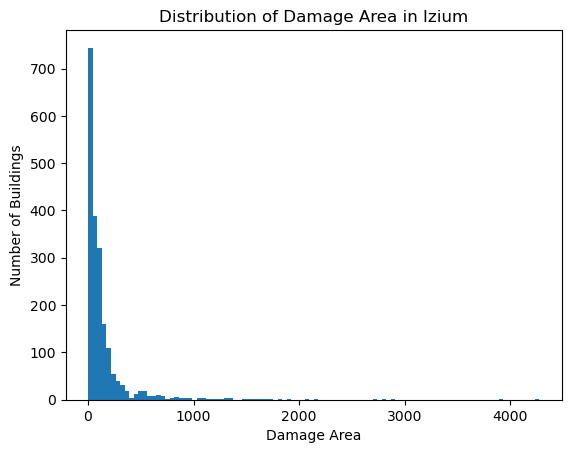

In [91]:
# plot distribution of damageArea
plt.hist(shapefile_subset.damageArea, bins=100)

# add xlabel, ylabel, title
plt.xlabel('Damage Area')
plt.ylabel('Number of Buildings')
plt.title('Distribution of Damage Area in Izium')
plt.show()

# tif file (timestamps)

In [92]:
tif

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x17e0965e0> >

In [93]:
# convert tif to dataframe
band = tif.GetRasterBand(1)
array = band.ReadAsArray()

In [94]:
array.shape

(2296, 4297)

In [95]:
# convert array to dataframe

tif_df = pd.DataFrame(array)

# find which values are not NaN
tif_df = tif_df.dropna(how='all')
tif_df = tif_df.dropna(axis=1, how='all')

tif_df

,1710,1711,1712,1713,1714,1715,1716,1717,1718,1719,...,4256,4257,4258,4259,4260,4261,4262,4263,4264,4265
503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.648771e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.648771e+12,1.648771e+12,1.648771e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
505,NaN,NaN,NaN,NaN,NaN,NaN,1.648771e+12,1.648771e+12,1.648771e+12,1.648771e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.648771e+12,1.648771e+12,1.648771e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.648771e+12,1.648771e+12,1.648771e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
# find max and min of all values in tif_dif
max_val = tif_df.max().max()
min_val = tif_df.min().min()

# print max and min values
max_val, min_val

# convert UNIX timestamp to datetime
import datetime

def convert_unix_timestamp_to_datetime(unix_timestamp):
    # Convert the Unix timestamp to a datetime object
    datetime_object = datetime.datetime.fromtimestamp(unix_timestamp / 1000)

    # Format the datetime object to a string
    formatted_date = datetime_object.strftime('%Y-%m-%d %H:%M:%S')

    return formatted_date


In [97]:
# first timestamp of damaged building in Izium
convert_unix_timestamp_to_datetime(min_val)

'2022-02-28 23:59:06'

In [98]:
# last timestamp of damaged building in Izium
convert_unix_timestamp_to_datetime(max_val)

'2023-09-01 00:59:52'

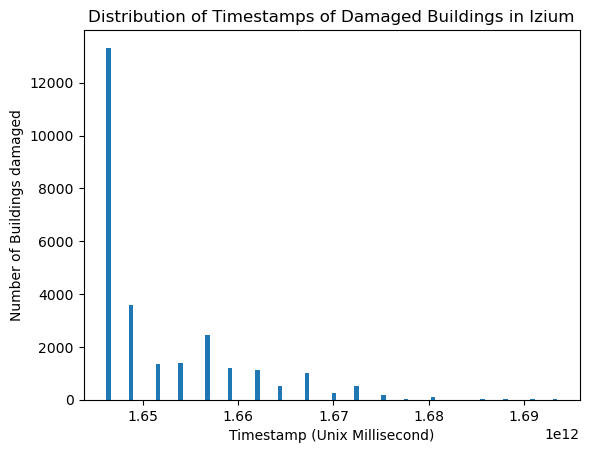

In [99]:
# plot histogram of values (unix millisecond timestamps)
plt.hist(tif_df.values.flatten(), bins=100)
plt.xlabel('Timestamp (Unix Millisecond)')
plt.ylabel('Number of Buildings damaged')
plt.title('Distribution of Timestamps of Damaged Buildings in Izium')
plt.show()

In [100]:
# Open the .tif file
file_path = 'izium_timestamped_damage_data_sample.tif'

# print all metadata of the tif file
with tifffile.TiffFile(file_path) as tif:
    # Get the metadata (tags) of the TIFF file
    for page in tif.pages:
        for tag in page.tags.values():
            tag_name = tag.name
            tag_value = tag.value
            print(f"{tag_name}: {tag_value}")

# Alternatively, you can use the PIL library to open and show the image
image = Image.open(file_path)
image.show()

ImageWidth: 4297
ImageLength: 2296
BitsPerSample: 32
Compression: 5
PhotometricInterpretation: 1
SamplesPerPixel: 1
PlanarConfiguration: 1
Predictor: 1
TileWidth: 256
TileLength: 256
TileOffsets: (2500, 4365, 6230, 8095, 9960, 11825, 13690, 15555, 17420, 19285, 21150, 23015, 24880, 26745, 28610, 30475, 32340, 34842, 36707, 38572, 40437, 42302, 44167, 46032, 48004, 49869, 51734, 53599, 55464, 57329, 59194, 61059, 62924, 64789, 67291, 69156, 71021, 72886, 74751, 76616, 78481, 80998, 83809, 89500, 94089, 96797, 98662, 100527, 102392, 104257, 106122, 108624, 110489, 112354, 114219, 116084, 117949, 119814, 121679, 126723, 130647, 133622, 135519, 138293, 140680, 142545, 144410, 146275, 148777, 150642, 152507, 154372, 156237, 158102, 159967, 161832, 165957, 169813, 174897, 176762, 178627, 180492, 182357, 184222, 186771, 189384, 191249, 193114, 194979, 196844, 198709, 200574, 202439, 204304, 206197, 209437, 211302, 213167, 215032, 216897, 218762, 220627, 223624, 225489, 227354, 229219, 231084,